In [1]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

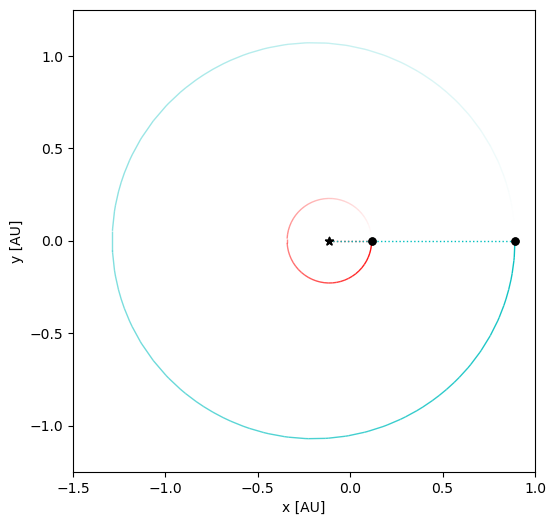

In [2]:
sim = rebound.Simulation()
sim.units = ('yr', 'AU', 'Msun')
sigma = 5.67037442e-08 * (365.25*86400) * (1.49597871e+11)**2 # J/(yr*AU**2*K**4)
m_A = 1.0479
R_A = 1.1618*695700000/1.49597871e+11
m_B = 1.0208
R_B = 1.0927*695700000/1.49597871e+11
m_P = 0.220*1.8981246e+27/1.98840987e+30
R_P = 0.764*71492000/1.49597871e+11
a_P = 1.0896
e_P = 0.182
i_P = 90.355

M = m_A + m_B
a_sep = 0.22882
a_A = (m_B / M) * a_sep
a_B = (m_A / M) * a_sep
omega = np.sqrt(sim.G*M/a_sep**3)

v_A = omega*a_A
v_B = omega*a_B
sim.add(m=m_A, x=-a_A, y=0, z=0, vx=0, vy=-v_A, vz=0)
sim.add(m=m_B, x=a_B, y=0, z=0, vx=0, vy=v_B, vz=0)

v_P = np.sqrt(sim.G*(M+m_P)/(a_P*(1-e_P**2)))*(1+e_P)
sim.add(m=m_P, x=a_P*(1-e_P), y=0, z=0, vx=0, vy=v_P, vz=0)

op = rebound.OrbitPlot(sim, figsize=(6,6), unitlabel="[AU]", color=True, periastron=True, xlim=[-1.5,1.0], ylim=[-1.25,1.25])
op.fig.savefig("orbit.png", format='png', dpi=300, bbox_inches='tight', pad_inches=0.2)

C:\Users\lgm\AppData\Local\Temp\ipykernel_39828\2834905511.py:25: RuntimeWarning: invalid value encountered in arccos
  theta = np.arccos((r_BX**2+r_PX**2-r_BP**2)/(2*r_BX*r_PX))


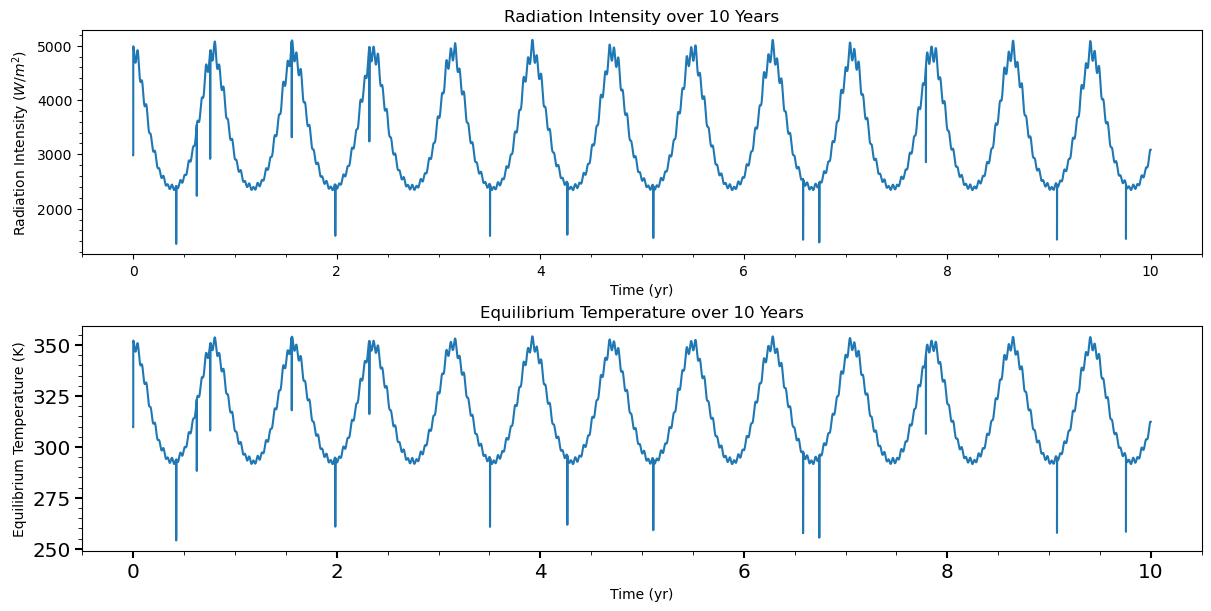

In [3]:
sim.integrator = "ias15"
dt = 0.00001
t_end = 10.0
n_steps = int(t_end/dt)

radiation_intensity = np.zeros(n_steps)
equilibrium_temperature = np.zeros(n_steps)

for i in range(n_steps):
    sim.integrate(sim.t + dt)

    r_A = np.array(sim.particles[0].xyz)
    r_B = np.array(sim.particles[1].xyz)
    r_P = np.array(sim.particles[2].xyz)

    r_AB = np.linalg.norm(r_B - r_A)
    r_AP = np.linalg.norm(r_P - r_A)
    r_BP = np.linalg.norm(r_P - r_B)

    r_BX = r_AB/(R_A/R_B-1)
    r_X = r_B*(1+r_BX/a_B)
    r_PX = np.linalg.norm(r_X - r_P)

    theta_crit = np.arcsin(R_B/r_BX)
    theta = np.arccos((r_BX**2+r_PX**2-r_BP**2)/(2*r_BX*r_PX))

    T_A = 5913
    T_B = 5915
    L_AP = sigma*np.pi*R_P**2*(1-0.3)*(R_A**2*T_A**4/r_AP**2)
    L_BP = sigma*np.pi*R_P**2*(1-0.3)*(R_B**2*T_B**4/r_BP**2)
    if theta<=theta_crit:
        if r_PX<r_BX:
            L = L_BP
        else:
            L = L_AP
    else:
        L = L_AP + L_BP

    T_eq = np.power(L/(4*np.pi*R_P**2*sigma),0.25)
    I = L/(np.pi*R_P**2*(1-0.3)) # J/(yr*AU**2)
    radiation_intensity[i] = I / (365.25*86400 * (1.49597871e+11)**2) # W/m^2
    equilibrium_temperature[i] = T_eq # K

time = np.linspace(0, t_end, n_steps)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,6), layout='constrained')
ax1.plot(time, radiation_intensity)
ax1.set_xlabel('Time (yr)')
ax1.set_ylabel(r'Radiation Intensity ($W/m^2$)')
ax1.set_title('Radiation Intensity over 10 Years')
ax2.plot(time, equilibrium_temperature)
ax2.set_xlabel('Time (yr)')
ax2.set_ylabel('Equilibrium Temperature (K)')
ax2.set_title('Equilibrium Temperature over 10 Years')
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
plt.tick_params(which='major',length=5,width=1.5,labelsize='x-large')
plt.tick_params(which='minor',length=3)
plt.show()
fig.savefig('variation.png', format='png', dpi=300, bbox_inches='tight', pad_inches=0.2)